# LSTM Stock Price Prediction

- LSTM -> Long Short Term Memory

## Requirements

In [2]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import root_mean_squared_error
from torch.utils.data import Dataset
import seaborn as sns
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler


## Tutorials
- **(Greg Hogg, 2023)** Video: https://www.youtube.com/watch?v=q_HS4s1L8UI&t=147s
- **(NeuralNine, 2025)** Video: https://www.youtube.com/watch?v=IJ50ew8wi-0

## Load Data

In [3]:
df = pd.read_csv('../data/combined_output.csv')

df.head()

,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,...,3_day_max,3_day_min,5_day_max,5_day_min,day_of_week,numerical_sentiment,mean_sentiment_probability,percent_positive,percent_negative,percent_neutral
0,2026-01-27,672.97,676.8150,664.6600,674.59,13148719,672.407383,676.249169,664.104331,674.026029,...,676.8150,661.2855,676.8150,661.2855,2,0.158879,0.790941,0.299065,0.140187,0.560748
1,2026-01-28,668.73,677.6775,666.1000,674.50,25709600,668.170928,677.110948,665.543127,673.936104,...,677.6775,661.2855,677.6775,661.2855,3,0.170543,0.801010,0.302326,0.131783,0.565891
2,2026-01-29,738.31,744.0000,712.5500,737.43,59852903,737.692758,743.378001,711.954294,736.813493,...,744.0000,664.6600,744.0000,661.2855,4,-0.027027,0.806134,0.209459,0.236486,0.554054
3,2026-01-30,716.50,732.1700,713.5900,727.50,23744573,715.900991,731.557891,712.993424,726.891795,...,744.0000,666.1000,744.0000,661.2855,5,-0.109375,0.837781,0.156250,0.265625,0.578125
4,2026-02-02,706.41,721.3000,703.5201,714.60,14365224,705.819427,720.696978,702.931943,714.002580,...,721.3000,703.5201,744.0000,703.5201,1,-0.076923,0.814024,0.153846,0.230769,0.615385


## Check Device

In [4]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu:1'

device

'cpu:1'

## Lag Features

In [5]:
columns = df.columns

day = 1

df = df.set_index('date')

df['previous_day_numerical_sentiment'] = df['numerical_sentiment'].shift(day)
df['previous_day_mean_sentiment_probability'] = df['mean_sentiment_probability'].shift(day)
df['previous_day_percent_positive'] = df['percent_positive'].shift(day)
df['previous_day_percent_negative'] = df['percent_negative'].shift(day)
df['previous_day_percent_neutral'] = df['percent_neutral'].shift(day)

df = df.drop(columns=['high',
                      'low',
                      'open',
                      'volume',
                      'adjClose',
                      'adjHigh',
                      'adjLow',
                      'adjOpen',
                      'adjVolume',
                      'divCash',
                      'splitFactor',
                      'numerical_sentiment',
                      'mean_sentiment_probability',
                      'percent_positive',
                      'percent_negative',
                      'percent_neutral',])

df.iloc[2]

close                                      7.383100e+02
previous_day_close                         6.687300e+02
previous_day_high                          6.776775e+02
previous_day_low                           6.661000e+02
previous_day_open                          6.745000e+02
previous_day_volume                        2.570960e+07
1_day_max                                  7.440000e+02
1_day_min                                  7.125500e+02
3_day_max                                  7.440000e+02
3_day_min                                  6.646600e+02
5_day_max                                  7.440000e+02
5_day_min                                  6.612855e+02
day_of_week                                4.000000e+00
previous_day_numerical_sentiment           1.705426e-01
previous_day_mean_sentiment_probability    8.010101e-01
previous_day_percent_positive              3.023256e-01
previous_day_percent_negative              1.317829e-01
previous_day_percent_neutral               5.658

## Plot

[Text(0.5, 0, 'Date'), Text(0, 0.5, 'Closing Price')]

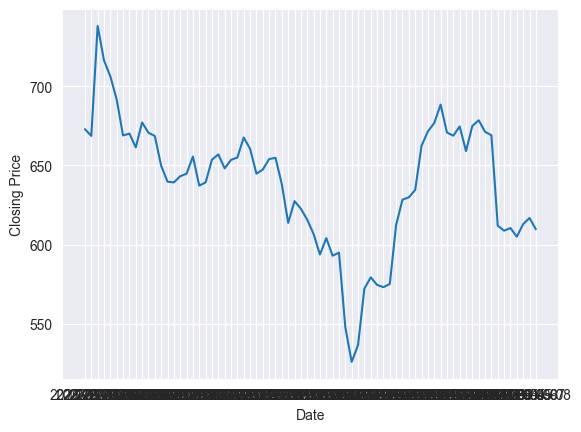

In [6]:
line_graph = sns.lineplot(x='date', y='close', data=df)
line_graph.set(xlabel='Date', ylabel='Closing Price')

## Remove Rows With Nulls

In [22]:
df = df.dropna()

df.to_csv('../data/model_ready.csv')

## Scale Data

In [8]:
scalar_x = StandardScaler()
scalar_y = StandardScaler()

X_df = df.iloc[:,1:]
Y_df = df.iloc[:, [0]]

train_size = int(len(df) * 0.7)

X_train_df_as_numpy = scalar_x.fit_transform(X_df[:train_size]) # Fit to training data
X_test_df_as_numpy = scalar_x.transform(X_df[train_size:])
Y_train_df_as_numpy = scalar_y.fit_transform(Y_df[:train_size]) # Don't fit to test data as it will cause data leakage
Y_test_df_as_numpy = scalar_y.transform(Y_df[train_size:])


X_train_df_as_numpy

array([[ 8.40131165e-01,  7.16429237e-01,  8.60974407e-01,
         8.43508922e-01, -3.30553118e-01,  7.60506226e-01,
         9.29579105e-01,  5.86239371e-01,  1.01009025e+00,
         4.88673593e-01,  1.05266791e+00,  0.00000000e+00,
         1.63740501e+00, -1.18117762e+00,  1.64722019e+00,
        -9.65215287e-01, -2.89195602e-01],
       [ 7.44442524e-01,  7.35765768e-01,  8.94102653e-01,
         8.41474729e-01,  1.10374189e+00,  2.25387782e+00,
         1.99967135e+00,  2.11333791e+00,  1.08992498e+00,
         2.02334748e+00,  1.05266791e+00,  7.29800449e-01,
         1.73319147e+00, -6.11971393e-01,  1.69416681e+00,
        -1.06064536e+00, -2.38578593e-01],
       [ 2.31472924e+00,  2.22266098e+00,  1.96271862e+00,
         2.26382788e+00,  5.00247870e+00,  1.98750387e+00,
         2.02363036e+00,  2.11333791e+00,  1.12399285e+00,
         2.02334748e+00,  1.05266791e+00,  1.45960090e+00,
         1.10738886e-01, -3.22317448e-01,  3.56886171e-01,
         1.28300575e-01, -3.5

## Split Data Train/Test

In [9]:
X_train = X_train_df_as_numpy.reshape((-1, 17, 1))
Y_train = Y_train_df_as_numpy.reshape((-1, 1))

X_test = X_test_df_as_numpy.reshape((-1, 17, 1))
Y_test = Y_test_df_as_numpy.reshape((-1, 1))

X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((49, 17, 1), (49, 1), (22, 17, 1), (22, 1))

## Convert To Tensors

In [10]:
X_train = torch.tensor(X_train).float()
Y_train = torch.tensor(Y_train).float()
X_test = torch.tensor(X_test).float()
Y_test = torch.tensor(Y_test).float()

X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

(torch.Size([49, 17, 1]),
 torch.Size([49, 1]),
 torch.Size([22, 17, 1]),
 torch.Size([22, 1]))

## Dataset Class

In [11]:
class StockDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [12]:
train_dataset = StockDataset(X_train, Y_train)
test_dataset = StockDataset(X_test, Y_test)

train_dataset.__len__()

49

## Dataloaders

In [13]:
train_dataloader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=False,
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
)

train_dataloader

In [14]:
for _, batch in enumerate(train_dataloader):
    x_batch, y_batch = batch[0].to(device), batch[1].to(device)
    print(x_batch.shape, y_batch.shape)


torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([1, 17, 1]) torch.Size([1, 1])


## Define Neural Network

In [15]:
class Net(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        batch_size = x.shape[0]
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

In [16]:
model = Net(1, 32, 4, 1)
model.to(device)
model

Net(
  (lstm): LSTM(1, 32, num_layers=4, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

## Training Loop

In [17]:
lr = 1e-3
num_epochs = 500
loss_function = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

for epoch in range(num_epochs):
    optimizer.zero_grad()
    output = model(X_train)
    loss = loss_function(output, Y_train)

    if epoch % 25 == 0:
        # Every 25 epochs
        print(epoch, loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()



0 1.0007585287094116
25 0.38185954093933105
50 0.18680422008037567
75 0.1378776878118515
100 0.11197070777416229
125 0.10112466663122177
150 0.09910757839679718
175 0.09742265939712524
200 0.09549493342638016
225 0.09290677309036255
250 0.08873722702264786
275 0.08079260587692261
300 0.07046258449554443
325 0.05420578271150589
350 0.04724128544330597
375 0.029365787282586098
400 0.02587238699197769
425 0.02482219599187374
450 0.020059973001480103
475 0.019372932612895966


## Testing

In [18]:
model.eval()

test_output_prediction = model(X_test)

train_output_prediction = scalar_y.inverse_transform(output.detach().cpu().numpy())
train_actual = scalar_y.inverse_transform(Y_train.detach().cpu().numpy())
test_output_prediction = scalar_y.inverse_transform(test_output_prediction.detach().cpu().numpy())
test_actual = scalar_y.inverse_transform(Y_test.detach().cpu().numpy())

train_output_prediction.shape, train_actual.shape, test_output_prediction.shape, test_actual.shape

((49, 1), (49, 1), (22, 1), (22, 1))

In [19]:
train_rmse = root_mean_squared_error(train_actual, train_output_prediction)
test_rmse = root_mean_squared_error(test_actual, test_output_prediction)


In [20]:
{'train_rmse' :train_rmse, 'test_rmse':test_rmse}

{'train_rmse': 5.70527458190918, 'test_rmse': 14.051664352416992}

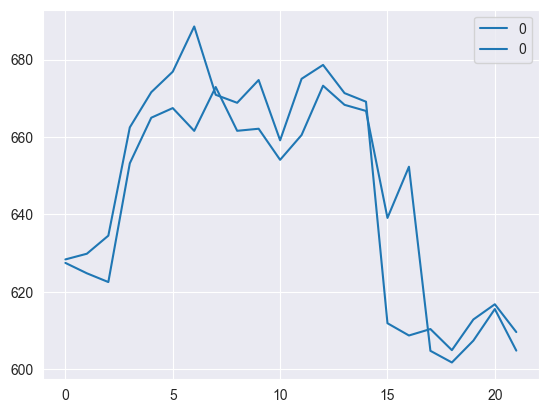

In [21]:


actual_line = sns.lineplot(test_actual)
predicted_line = sns.lineplot(test_output_prediction)

